# DESeq2 with new reference genome
# Phase 1 vs. Phase 1

focusing on pairwise comparisons involving oysters that experienced only **one** phase 1 (one exposure)

## 0. load libraries

In [19]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)
library(vegan)
library(pheatmap)
library(RColorBrewer)

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [20]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts <- counts %>%
select(-Gene_ID, -Length)

head(counts)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### meta data

In [21]:
# create df with col names from counts matrix
meta <- as.data.frame(colnames(counts))

colnames(meta) <- 'Sample'

# Separate into columns
meta <- meta %>%
   # Keep original SampleID
  mutate(OGSample = Sample) %>%
  # Split by '_'
  separate(Sample, into = c("Phase1", "Phase2", "Tag"), sep = "_") %>%
  mutate(
    Phase1_Treatment = substr(Phase1, 1, 1),
    Phase1_TankRep    = as.numeric(substr(Phase1, 2, nchar(Phase1))),
    Phase2_Treatment = gsub("[0-9]", "", Phase2),
    Phase2_TankRep       = as.numeric(gsub("[A-Za-z]", "", Phase2))
  ) %>%
  select(OGSample, Phase1_Treatment, Phase1_TankRep, Phase2_Treatment, Phase2_TankRep, Tag)

colnames(meta)[1] <- 'Sample'

head(meta)

,Sample,Phase1_Treatment,Phase1_TankRep,Phase2_Treatment,Phase2_TankRep,Tag
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
1,B1_B1_O01,B,1,B,1,O01
2,B1_Nu_O03,B,1,Nu,NA,O03
3,B1_W5_O50,B,1,W,5,O50
4,B2_B5_O51,B,2,B,5,O51
5,B2_C4_O40,B,2,C,4,O40
6,B2_Nu_O12,B,2,Nu,NA,O12


In [22]:
# adding treatment info
meta2 <- meta %>%
mutate(
    ## phase 1 treatments
    # overall
    Phase1_treatment = case_when(
        Phase1_Treatment == 'B' ~ 'both',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase1_temp = case_when(
        Phase1_Treatment == 'B' ~ 'warm',
        Phase1_Treatment == 'H' ~ 'ambient',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase1_DO = case_when(
        Phase1_Treatment == 'B' ~ 'hypoxic',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'normoxic',
        Phase1_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_),
    
    ## phase 2 treatments
    # overall
    Phase2_treatment = case_when(
        Phase2_Treatment == 'B' ~ 'both',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase2_temp = case_when(
        Phase2_Treatment == 'B' ~ 'warm',
        Phase2_Treatment == 'H' ~ 'ambient',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase2_DO = case_when(
        Phase2_Treatment == 'B' ~ 'hypoxic',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'normoxic',
        Phase2_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_)) %>%
select(Sample, Phase1_treatment, Phase1_temp, Phase1_DO, Phase1_TankRep, Phase2_treatment, Phase2_temp, Phase2_DO, Phase2_TankRep)

head(meta2)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [6]:
#write.csv(meta2, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/sample_metaData.csv', row.names=FALSE)

for this analysis, only looking at Phase 1 samples, so pulling those out

In [7]:
# if skipped above code:
meta2 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

In [23]:
# selecting only phase 1 sample
p1_meta <- meta2 %>%
filter(grepl("Nu", Sample)) %>%
filter(Sample != 'B3_Nu_O24') # this sample failed all QC steps, removing from analysis

# setting samples as rownames and deleting col from df
rownames(p1_meta) <- p1_meta$Sample
p1_meta <- p1_meta[, !colnames(p1_meta) %in% "Sample"]

p1_meta

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA
C2_Nu_W15,control,ambient,normoxic,2,NA,NA,NA,NA
C3_Nu_W21,control,ambient,normoxic,3,NA,NA,NA,NA


In [24]:
# pulling out only phase 1 counts
p1_counts <- counts[,colnames(counts) %in% rownames(p1_meta)]
head(p1_counts)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2649,3974,2721,2246,2606,2804,2840,2829,2376,3580,⋯,2518,2269,3011,3027,3384,2316,2342,3478,2734,2374
LOC144621269,580,20011,11469,21,86,9642,2179,2944,4120,3621,⋯,7163,2405,217,35998,11679,2489,3926,11926,2,4034
LOC111120925,4,18,27,2,8,22,339,350,269,7,⋯,301,15,238,167,9,284,6,7,0,11
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [25]:
# setting the same order for counts matrix and meta data
p1_counts <- p1_counts[,rownames(p1_meta)]
all(rownames(p1_meta) == colnames(p1_counts))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [9]:
# overall phase 1 treatment
p1_meta$Phase1_treatment <- factor(p1_meta$Phase1_treatment,
                                   levels = c('control', 'both', 'hypoxic', 'warm'))

In [10]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [11]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

### phase 1 overall treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [12]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_treatment)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

class: DESeqDataSet 
dim: 33903 23 
metadata(1): version
assays(1): counts
rownames(33903): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

33,903 genes to start

### pre-filter genes

In [13]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$Phase1_treatment)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 6 samples with counts of 10 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [14]:
dds_filtered

class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(4): counts mu H cooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(30): baseMean baseVar ... deviance maxCooks
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(10): Phase1_treatment Phase1_temp ... sizeFactor group

22343 genes after filtering

In [15]:
25196/33903
# kept ~75% of genes

[1] 0.7431791

#### run DESeq again

In [16]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [17]:
write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1_vst.csv')

### diagnostic tests

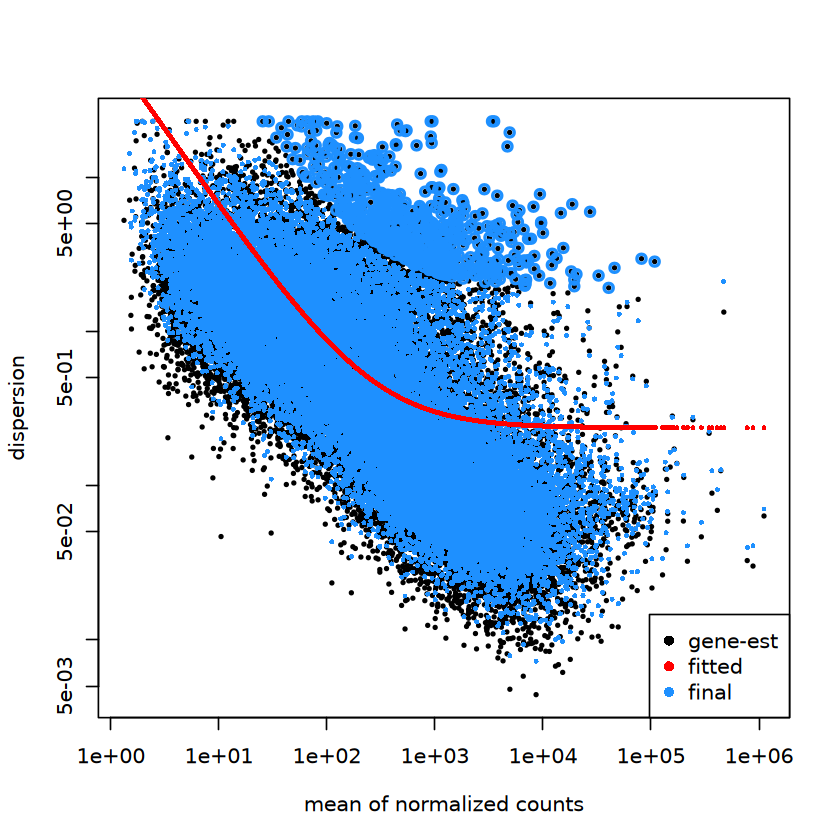

In [26]:
plotDispEsts(dds_filtered)

## nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [27]:
# normalization & transformation
vsd <- vst(dds_filtered, blind = FALSE)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.0000,172.0676,163.7663,148.2427,140.8442,156.1078,151.4854,162.5843,148.6235,143.7828,⋯,181.3153,148.5412,145.3274,199.1984,159.3238,154.6428,140.9241,156.3878,132.3680,148.5760
B2_Nu_O12,172.0676,0.0000,144.1658,193.4136,183.1232,140.4477,161.6368,164.4364,157.6985,143.4971,⋯,153.0460,149.1555,186.7158,146.7718,151.2684,158.9952,157.5580,145.8091,177.7005,146.2685
B4_Nu_O32,163.7663,144.1658,0.0000,174.2239,168.0534,148.4859,149.5726,147.2499,144.6350,144.8047,⋯,156.7922,108.2964,170.6913,149.2250,145.8398,156.0325,160.8244,139.6110,176.7033,141.5935
B5_Nu_O36,148.2427,193.4136,174.2239,0.0000,140.6526,180.9066,159.6940,161.9214,154.0008,167.7287,⋯,193.9648,159.2193,146.1800,208.9611,164.3245,175.9368,178.9654,172.1511,162.0573,163.2247
B6_Nu_O47,140.8442,183.1232,168.0534,140.6526,0.0000,170.3497,158.5765,151.2281,149.7721,156.1622,⋯,176.7102,149.0343,141.3860,204.7333,151.7577,171.0803,166.5323,150.0178,151.5072,151.8489
C1_Nu_W01,156.1078,140.4477,148.4859,180.9066,170.3497,0.0000,149.9222,157.3227,150.6997,133.5558,⋯,155.9097,147.0431,175.0169,159.7486,138.6484,150.4885,151.0790,140.5181,162.7350,140.9570


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor,group
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>
B1_Nu_O03,57.95982,-34.939589,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324,both
B2_Nu_O12,-61.96924,-34.671208,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462,both
B4_Nu_O32,-34.28842,-1.585018,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377,both
B5_Nu_O36,79.76763,16.991191,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641,both
B6_Nu_O47,67.33204,1.352514,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226,both
C1_Nu_W01,-34.36848,-40.760884,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061,control


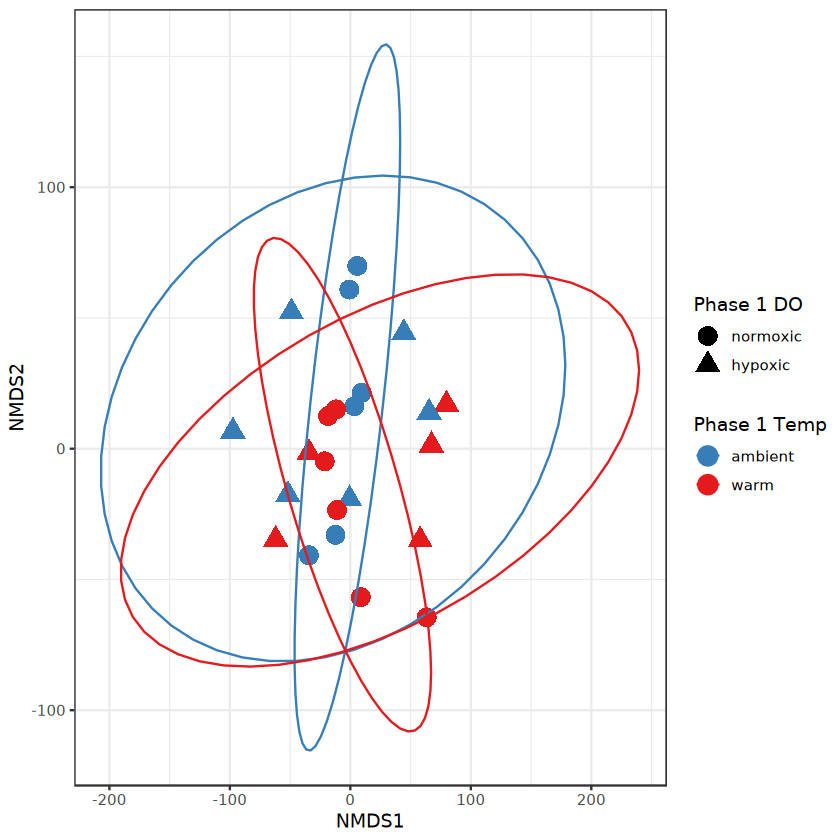

In [28]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
stat_ellipse() + 
scale_color_brewer(palette = 'Set1', direction = -1) +
theme_bw() +
labs(x = 'NMDS1',
     y = 'NMDS2',
     col = 'Phase 1 Temp',
     shape = 'Phase 1 DO')

nmds.plot

There doesn't appear to be any strong patterns of gene expression among the different phase 1 treatments

but the warm treatment looks less disperse than ambient treatment

#### permANOVA

In [29]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO, data = p1_meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,15171.49,0.05589905,1.2294576,0.138
Phase1_DO,1,11628.32,0.04284430,0.9423281,0.519
Phase1_temp:Phase1_DO,1,10149.18,0.03739443,0.8224623,0.790
Residual,19,234459.79,0.86386223,NA,NA
Total,22,271408.78,1.00000000,NA,NA


permANOVA confirms that there isn't any statistically significant differences in gene expression patterns among phase 1 treatments 

### heatmap

In [30]:
# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 172.0676 163.7663 148.2427 140.8442 156.1078 151.4854

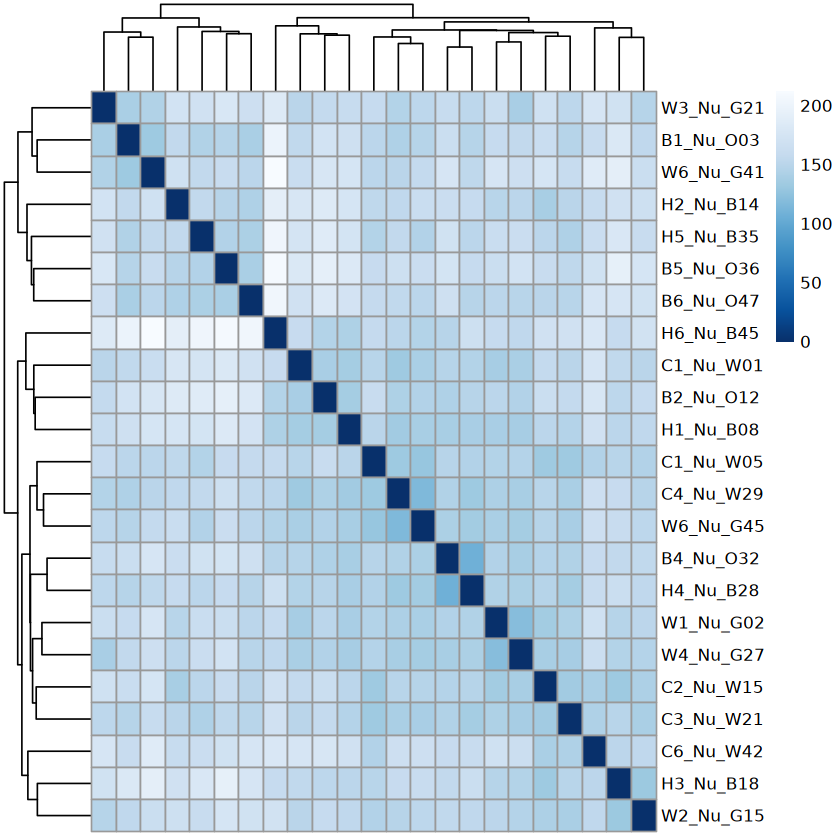

In [31]:
sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

### comparisons vs. control
applying `ashr` lfc shrinkage estimator - DESeq docs recommend `apeglm` but cannot use that for comparisons below so I want everything to be consistent

In [32]:
resultsNames(dds_filtered)

[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

#### warm vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 54, 0.21%
LFC < 0 (down)     : 75, 0.3%
outliers [1]       : 262, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


log2 fold change (MMSE): Phase1_treatment warm vs control 
Wald test p-value: Phase1 treatment warm vs control 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  2772.766     0.00388526 0.0531620 0.78621234  0.985448
LOC144621269  6797.381     0.00380193 0.1046955 0.66121266  0.978852
LOC111120925   191.443    -0.15664648 0.6482279 0.00954929  0.380963
LOC144621283   932.054     0.00691118 0.0572034 0.63313047  0.974611
LOC144621276 12350.889     0.01483559 0.0673080 0.34063104  0.908150
LOC111115920   213.339    -0.00322904 0.0658101 0.80154684  0.987502

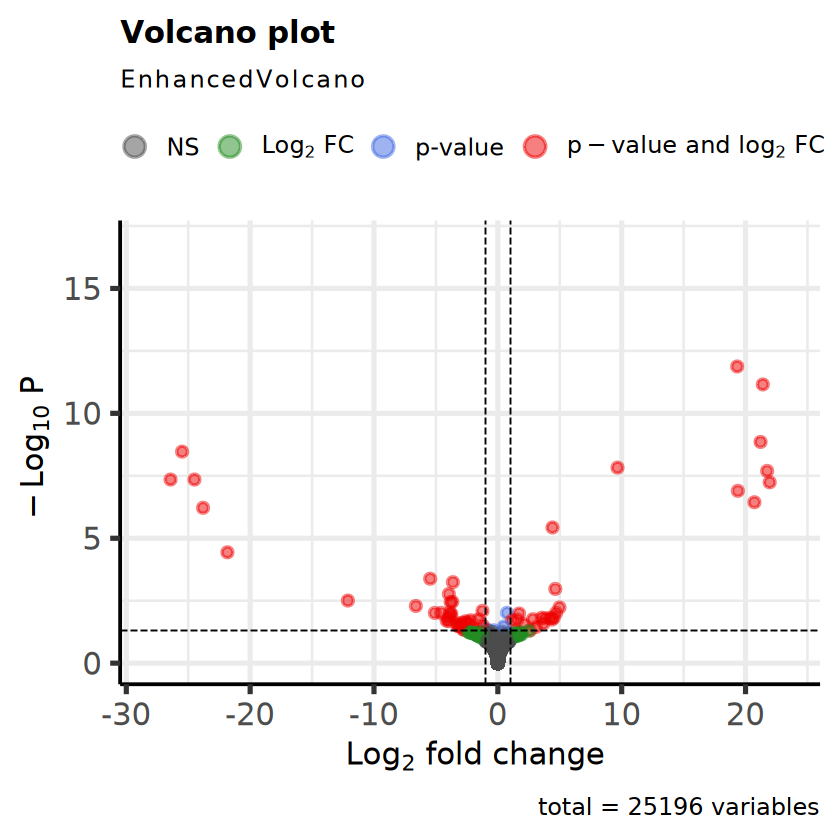

In [33]:
# phase 1 warm vs. control
res.warmLFC <- lfcShrink(dds_filtered, 
                         contrast = c('Phase1_treatment', 'warm', 'control'), 
                         type = 'ashr')

summary(res.warmLFC)

EnhancedVolcano(res.warmLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.warmLFC)[1] <- 'Gene'
head(res.warmLFC)

In [34]:
write.csv(as.data.frame(res.warmLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_cont.csv')

#### hypoxic vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 34, 0.13%
LFC < 0 (down)     : 24, 0.095%
outliers [1]       : 262, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs control 
Wald test p-value: Phase1 treatment hypoxic vs control 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  2772.766     0.00805632 0.0413073  0.349542  0.972902
LOC144621269  6797.381     0.00657404 0.1090845  0.139642  0.927967
LOC111120925   191.443    -0.00674354 0.1106457  0.135048  0.927967
LOC144621283   932.054    -0.01123526 0.0426901  0.161982  0.942168
LOC144621276 12350.889     0.00504380 0.0415322  0.485809  0.987427
LOC111115920   213.339     0.00176373 0.0421061  0.739785  0.990003

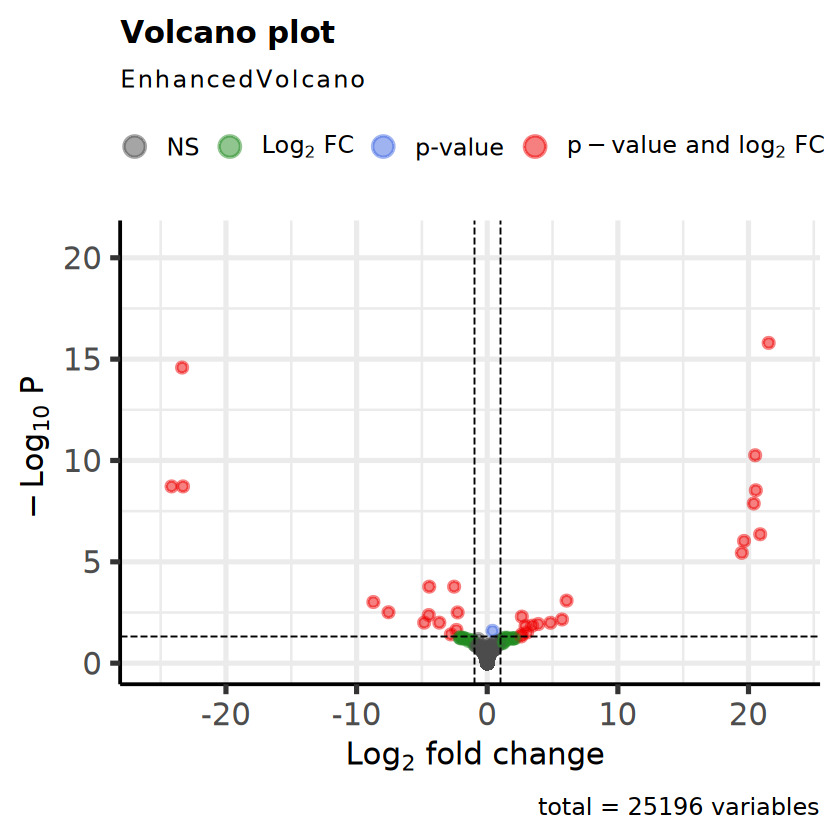

In [35]:
# phase 1 hypoxic vs. control
res.hypoxicLFC <- lfcShrink(dds_filtered, 
                            contrast = c('Phase1_treatment', 'hypoxic', 'control'),
                            type = 'ashr')

summary(res.hypoxicLFC)

EnhancedVolcano(res.hypoxicLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.hypoxicLFC)[1] <- 'Gene'
head(res.hypoxicLFC)

In [36]:
write.csv(as.data.frame(res.hypoxicLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv')

#### both vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 97, 0.38%
LFC < 0 (down)     : 235, 0.93%
outliers [1]       : 262, 1%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment both vs control 
Wald test p-value: Phase1 treatment both vs control 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange     lfcSE      pvalue       padj
             <numeric>      <numeric> <numeric>   <numeric>  <numeric>
LOC144621260  2772.766     0.00067618 0.0222836 7.78713e-01 0.99675384
LOC144621269  6797.381     0.00430872 0.1099699 5.81377e-01 0.99202879
LOC111120925   191.443    -4.89646529 1.4092474 8.35454e-06 0.00358293
LOC144621283   932.054     0.00117828 0.0237116 6.19783e-01 0.99227534
LOC144621276 12350.889     0.00122661 0.0248093 5.97619e-01 0.99202879
LOC111115920   213.339     0.06763248 0.2503781 6.16003e-03 0.23487746

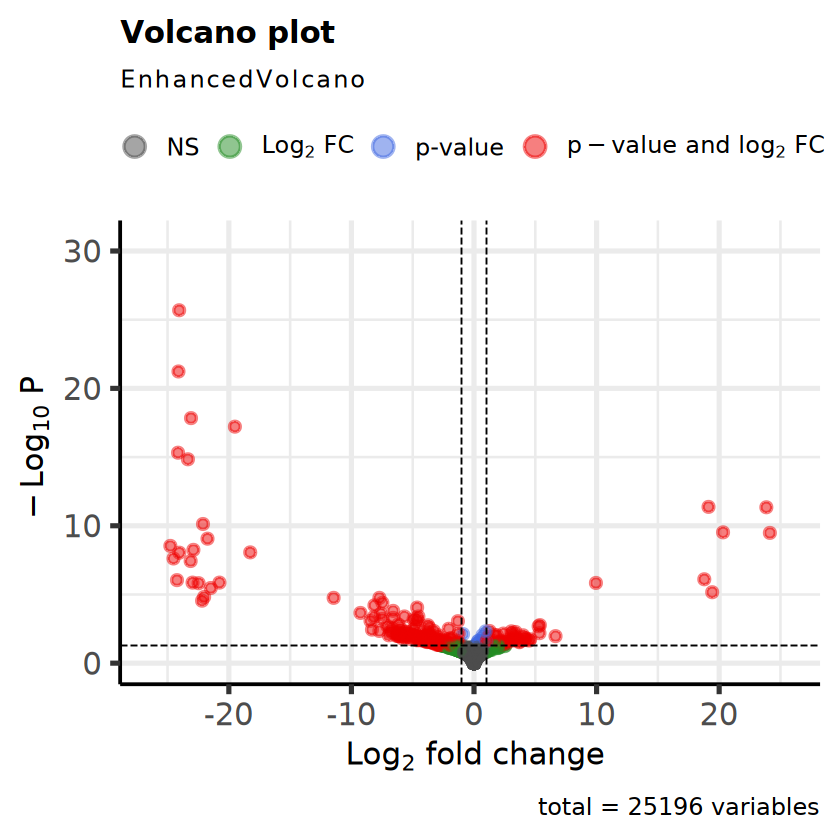

In [37]:
# phase 1 both vs. control
res.bothLFC <- lfcShrink(dds_filtered, 
                         contrast = c('Phase1_treatment', 'both', 'control'), 
                         type = 'ashr')

summary(res.bothLFC)

EnhancedVolcano(res.bothLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.bothLFC)[1] <- 'Gene'
head(res.bothLFC)

In [38]:
write.csv(as.data.frame(res.bothLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv')

### other comparisons
(outside of just doing treatment vs. control)

using `ashr` for lfc shrinkage estimator (same as above)

#### warm vs. hypoxic

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 58, 0.23%
LFC < 0 (down)     : 37, 0.15%
outliers [1]       : 262, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs warm 
Wald test p-value: Phase1_treatment hypoxic vs warm 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  2772.766      0.0503310  0.121653 0.5065504  0.868422
LOC144621269  6797.381      0.0291376  0.192327 0.2988568  0.762412
LOC111120925   191.443      0.0310271  0.194652 0.2720993  0.742574
LOC144621283   932.054     -0.1464334  0.138156 0.0607734  0.499892
LOC144621276 12350.889     -0.0184418  0.130419 0.7980213  0.956485
LOC111115920   213.339      0.0366938  0.145892 0.5598569  0.886139

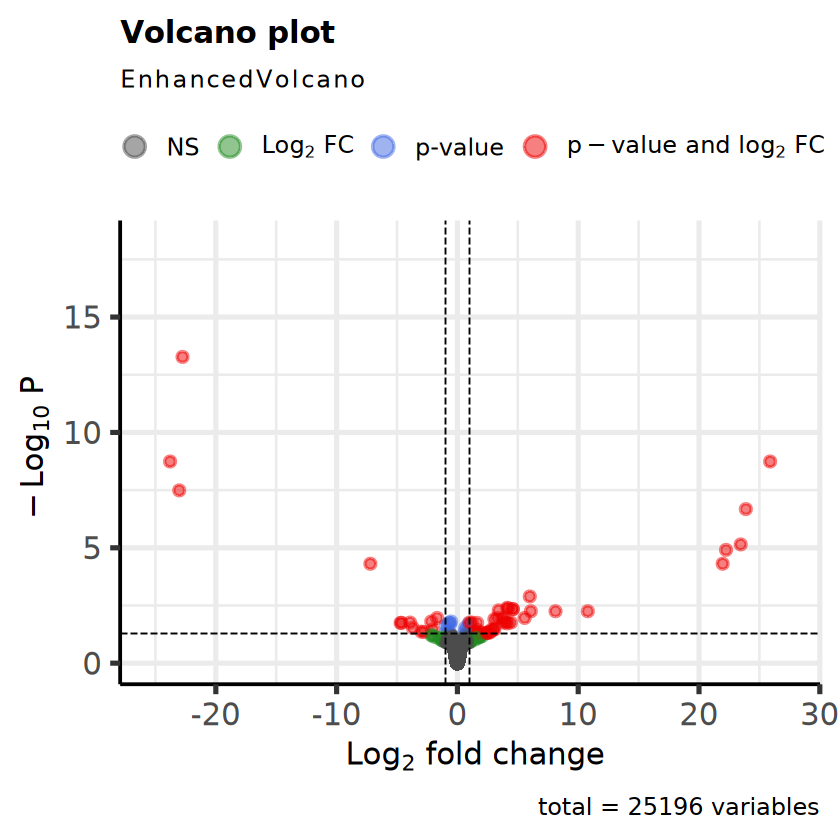

In [39]:
res.w.h <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'warm'), # warm is the "control"
                     type = 'ashr')

summary(res.w.h)

EnhancedVolcano(res.w.h,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.w.h)[1] <- 'Gene'
head(res.w.h)

In [40]:
write.csv(res.w.h, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv')

#### warm vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 78, 0.31%
LFC < 0 (down)     : 68, 0.27%
outliers [1]       : 262, 1%
low counts [2]     : 1462, 5.8%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment warm vs both 
Wald test p-value: Phase1_treatment warm vs both 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  2772.766    -0.00097376 0.0940134 0.98215404  0.998296
LOC144621269  6797.381    -0.00165848 0.1241712 0.89377510  0.988056
LOC111120925   191.443     0.05368370 0.3293103 0.04483007  0.550335
LOC144621283   932.054    -0.00168976 0.0960776 0.96732088  0.997314
LOC144621276 12350.889     0.01479406 0.0980936 0.70338989  0.957847
LOC111115920   213.339    -0.13626492 0.2351068 0.00290724  0.206998

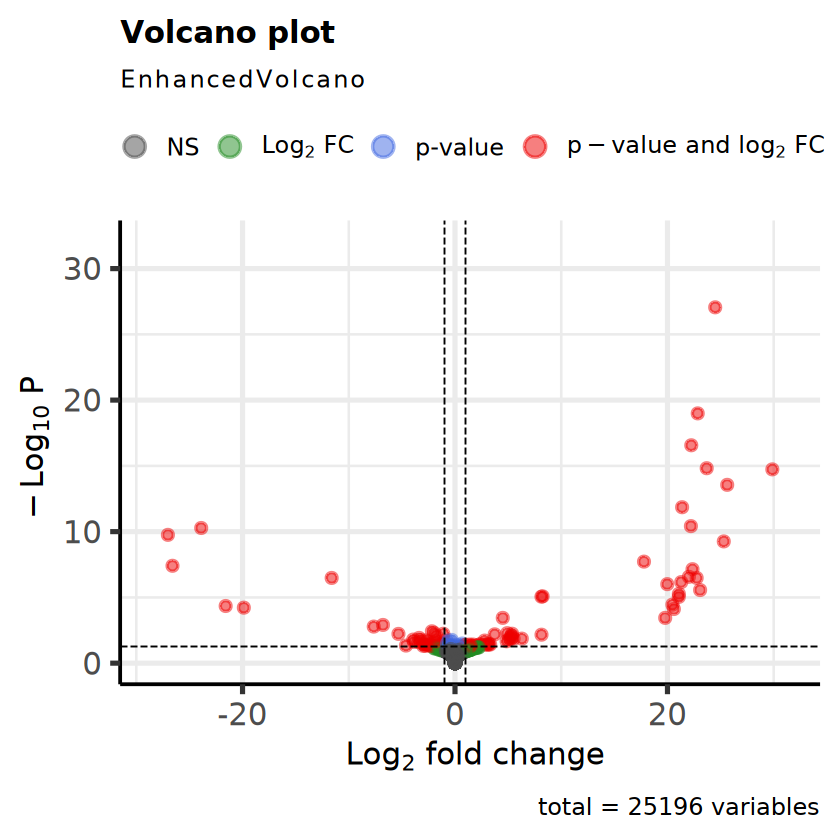

In [41]:
res.w.b <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'warm', 'both'), # both is the "control"
                     type = 'ashr')

summary(res.w.b)

EnhancedVolcano(res.w.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.w.b)[1] <- 'Gene'
head(res.w.b)

In [42]:
write.csv(res.w.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv')

#### hypoxic vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 133, 0.53%
LFC < 0 (down)     : 33, 0.13%
outliers [1]       : 262, 1%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs both 
Wald test p-value: Phase1_treatment hypoxic vs both 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange      lfcSE     pvalue      padj
             <numeric>      <numeric>  <numeric>  <numeric> <numeric>
LOC144621260  2772.766    2.37421e-04 0.00939428 0.54121176  0.985356
LOC144621269  6797.381    3.99519e-03 0.09777042 0.39143780  0.968167
LOC111120925   191.443    5.76801e-01 1.37772077 0.00232657  0.183437
LOC144621283   932.054   -1.64962e-03 0.02636311 0.06734813  0.714551
LOC144621276 12350.889    5.07574e-05 0.00961420 0.89123594  0.998889
LOC111115920   213.339   -1.33985e-02 0.11231696 0.01551890  0.429820

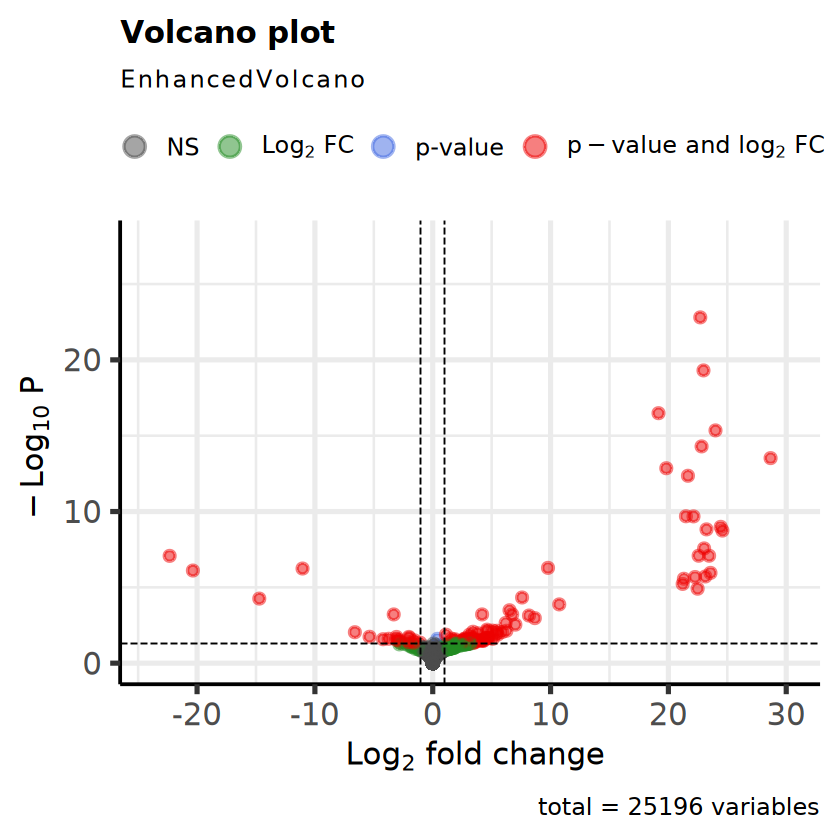

In [43]:
res.h.b <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'both'), # both is the "control"
                     type = 'ashr')

summary(res.h.b)

EnhancedVolcano(res.h.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.h.b)[1] <- 'Gene'
head(res.h.b)

In [44]:
write.csv(res.h.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv')

## DESeq - DO / warm treatments

nearly the same as above, but looking at the effect of hypoxia / warming (so normoxia includes C and W, hypoxia includes H and B; ambient includes C and H, warm includes W and B)

In [46]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

In [47]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [48]:
head(p1_meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


### phase 1 temperature
only comparing warming vs ambient (so some treatments are getting lumped together)

In [49]:
design(dds_filtered) <- ~ Phase1_temp
dds_temp <- DESeq(dds_filtered)
dds_temp

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1261 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 57, 0.23%
LFC < 0 (down)     : 150, 0.6%
outliers [1]       : 0, 0%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



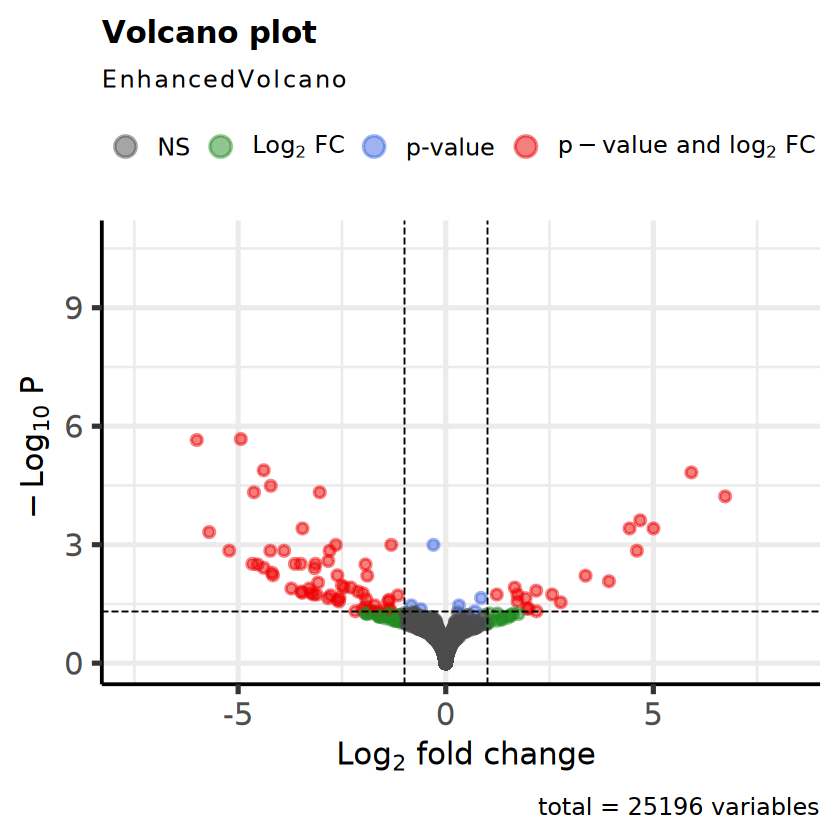

In [50]:
res.warm <- lfcShrink(dds_temp, 
                     contrast = c('Phase1_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(res.warm)

EnhancedVolcano(res.warm,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

interesting that there's not nearly as many DEGs when you only look at ambient vs. warm treatment ...

In [51]:
write.csv(res.warm, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/warm_v_ambient.csv')

### phase 1 DO
only comparing normoxia vs hypoxia (so some treatments are getting lumped together)

In [52]:
design(dds_filtered) <- ~ Phase1_DO
dds_DO <- DESeq(dds_filtered)
dds_DO

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1170 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 59, 0.23%
LFC < 0 (down)     : 30, 0.12%
outliers [1]       : 0, 0%
low counts [2]     : 1466, 5.8%
(mean count < 7)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



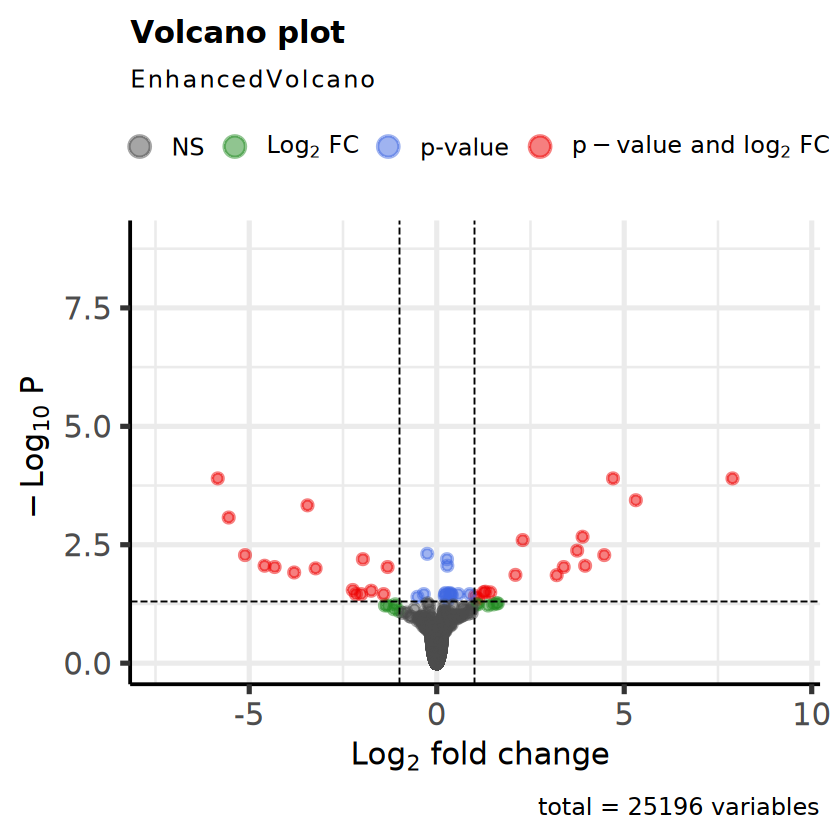

In [53]:
res.DO <- lfcShrink(dds_DO, 
                     contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(res.DO)

EnhancedVolcano(res.DO,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

same thing as temperature, not as many DEGs as when separating by treatment

In [55]:
write.csv(res.DO, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/hypoxic_v_normoxic.csv')

# I STOPPED HERE

### nMDS with only significant DEGs

In [54]:
# pull out all DEGs identified in any pairwise comparison
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
# want to keep only the dfs for full treatment comparisons - not isolated comparisons
geneList <- geneList[startsWith(names(geneList), "p1")]
names(geneList)

[1] "p1.both_v_cont" "p1.hyp_v_both"  "p1.hyp_v_cont"  "p1.hyp_v_warm" 
[5] "p1.warm_v_both" "p1.warm_v_cont"

In [60]:
# pull out DEGs in these dfs
degs <- lapply(geneList, function(df) {
      subset(df, abs(log2FoldChange) >= 1 & padj <= 0.05)
    })
head(degs$p1.both_v_cont)

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,LOC111120925,191.44305,-4.816061,1.434592,-4.432787,9.302274e-06,0.0030326606,0.003332593,3.429848,⋯,383.261217,14.374893,246.710448,219.685794,6.742502,337.801055,5.5715422,6.466452,0.000000,13.843829
211,211,LOC111103173,15.14959,4.365504,2.025135,4.039598,5.354287e-05,0.0106991246,0.022951093,129.476769,⋯,2.546586,6.708283,1.036599,2.630968,10.488336,0.000000,0.9285904,16.628020,0.000000,0.000000
232,232,LOC144622019,14.43126,-21.685053,4.272431,-5.354808,8.564740e-08,0.0000483984,0.000161978,0.000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
327,327,LOC111105159,57.17908,-5.199942,2.588591,-4.075872,4.584228e-05,0.0096385781,0.027797446,0.000000,⋯,1.273293,1.916652,1.036599,2.630968,1.498334,3.568321,0.0000000,3.695116,1.984959,0.000000
510,510,LOC111132252,110.19476,-2.635506,2.006382,-3.633249,2.798748e-04,0.0327889602,0.092730666,0.000000,⋯,146.428704,32.583090,350.370300,388.067720,35.210841,114.186272,43.6437471,15.704241,248.119838,3.775590
516,516,LOC111137262,591.06709,3.622591,3.009049,3.696540,2.185576e-04,0.0280691987,0.102579351,1.714924,⋯,2942.580305,1106.866737,13.475781,0.000000,4.495001,2653.641385,1.8571807,2366.721529,6.947355,7.551179


In [70]:
# create list of all DEGs from the four dfs
all_degs <- degs %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 429 total DEGs
head(all_degs)

[1] 429

[1] "LOC111120925" "LOC111103173" "LOC144622019" "LOC111105159" "LOC111132252"
[6] "LOC111137262"

In [71]:
vsd_mat <- assay(vsd)

degs_vsd <- vsd_mat[rownames(vsd_mat) %in% all_degs, ]

dim(degs_vsd) # 429 total DEGs kept
head(degs_vsd)

[1] 429  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111120925,6.790123,7.133028,7.222546,6.738875,6.949505,7.169359,9.046805,9.069082,8.527882,6.843712,⋯,9.104683,7.079873,8.675046,8.570575,6.901862,8.976325,6.866471,6.893820,6.510761,7.069393
LOC144621391,6.510761,6.510761,7.318804,8.320611,6.510761,8.001540,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
LOC144619144,6.905226,6.952462,6.706305,6.905049,6.510761,6.978463,7.955667,6.999780,8.089730,7.028005,⋯,7.245884,7.166524,6.817821,7.487426,7.783293,6.878205,8.260288,8.053211,8.585076,6.750179
LOC111103995,11.548996,12.622945,13.748478,13.152400,12.615797,13.140941,12.136580,12.391057,11.541497,13.309009,⋯,11.515983,13.716220,12.232161,11.007140,11.721038,11.266737,10.240734,10.172899,10.852696,10.959815
LOC111103173,8.141636,6.510761,7.329970,6.870880,8.124059,6.710904,6.510761,6.510761,6.510761,6.689013,⋯,6.751576,6.900875,6.664508,6.755523,6.997730,6.510761,6.656286,7.122240,6.510761,6.510761
LOC144622019,6.510761,6.510761,6.510761,6.510761,6.510761,8.486634,6.510761,6.510761,6.510761,8.158259,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761


In [72]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,25.58809,23.65612,26.39485,23.91285,29.23215,43.71596,42.99310,38.60694,28.86188,⋯,48.89620,26.48993,43.01986,31.68411,28.81443,41.81191,30.06913,30.15387,27.82811,28.10422
B2_Nu_O12,25.58809,0.00000,24.36756,27.07157,27.73877,26.26659,42.67010,42.74913,36.66925,26.72199,⋯,47.58784,25.77819,41.98810,27.81225,27.49891,39.62035,28.39594,30.98403,24.92026,27.47155
B4_Nu_O32,23.65612,24.36756,0.00000,21.49228,26.79378,26.47637,41.25209,40.53027,34.77507,25.40617,⋯,46.70719,19.02486,39.87266,26.42757,24.14030,39.14790,28.70278,27.51609,25.37509,25.16858
B5_Nu_O36,26.39485,27.07157,21.49228,0.00000,27.76026,28.35673,43.27916,42.93540,37.09021,28.79380,⋯,48.83519,22.82974,41.29170,30.19629,25.22638,42.87433,32.43042,29.74360,29.24598,26.98244
B6_Nu_O47,23.91285,27.73877,26.79378,27.76026,0.00000,31.55971,45.38393,44.75822,40.00159,30.73354,⋯,47.26734,26.44299,43.35675,34.77627,29.40650,43.54514,34.00883,30.12778,31.12411,30.13337
C1_Nu_W01,29.23215,26.26659,26.47637,28.35673,31.55971,0.00000,38.80417,39.09879,34.56847,22.28334,⋯,47.64610,24.77797,39.56868,26.21444,24.19144,39.63593,28.81359,27.22986,24.62407,22.82963


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
B1_Nu_O03,-12.758954,-9.100383,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324
B2_Nu_O12,-11.613427,-3.455909,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462
B4_Nu_O32,-11.302369,-5.853357,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377
B5_Nu_O36,-12.514332,-9.224793,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641
B6_Nu_O47,-12.634810,-13.249466,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226
C1_Nu_W01,-9.291786,3.105537,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061


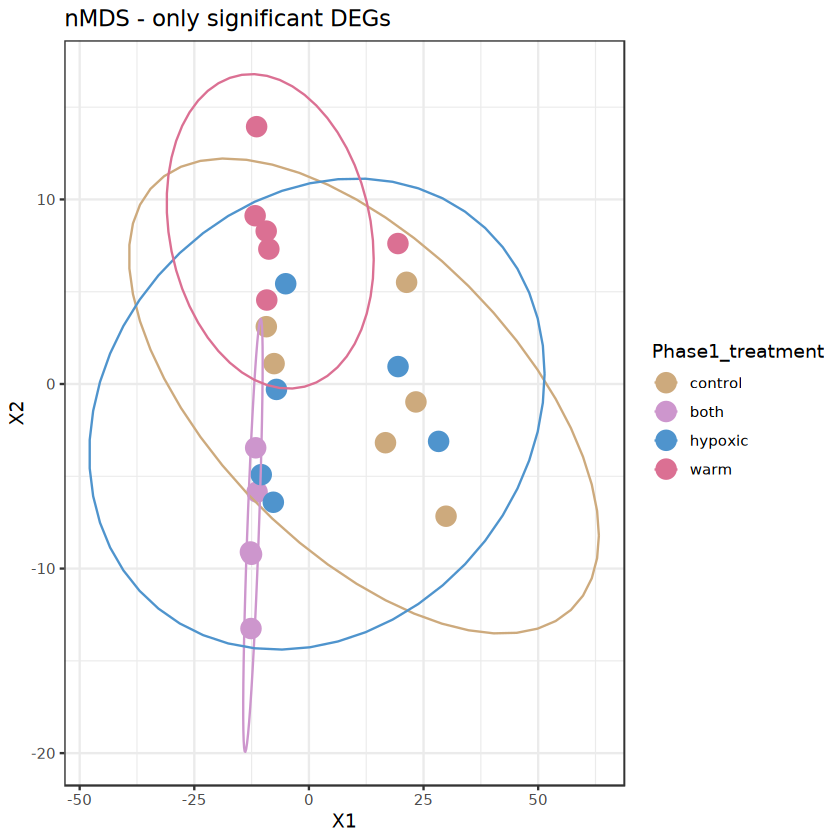

In [73]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

In [74]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

#### permanova

In [75]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,1926.6132,0.14972927,3.956629,0.004
Phase1_DO,1,1032.7009,0.08025771,2.120828,0.055
Phase1_temp:Phase1_DO,1,656.2702,0.05100290,1.347763,0.159
Residual,19,9251.7269,0.71901011,NA,NA
Total,22,12867.3113,1.00000000,NA,NA


significant effect of phase 1 temp, phase 1 DO no longer has a significant effect, and no interaction of the two stressors (there wasn't any significant effects when we looked at all genes, but once limited to significant DEGs idnetified in any pairwise comparison (not isolated treatments), we saw significant effects on GE profiles)

### nMDS with only significant DEGs from 'isolated' treatments

In [76]:
# pull out DEGs identified 

# read in dfs
do <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/hypoxic_v_normoxic.csv')
temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/warm_v_ambient.csv')

# merge
degs <- rbind(do, temp) %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1) 

deg_list <- unique(degs$X)
length(deg_list)# 112 total DEGs
head(deg_list)

[1] 112

[1] "LOC144621391" "LOC111105442" "LOC144622706" "LOC111105472" "LOC144625532"
[6] "LOC111101639"

In [77]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% deg_list,]

dim(degs_vsd) # 112 total DEGs kept
head(degs_vsd)

[1] 112  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC144621391,6.510761,6.510761,7.318804,8.320611,6.510761,8.001540,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
LOC111105159,6.510761,6.510761,6.706305,6.833028,6.666404,6.510761,8.914365,8.593003,6.510761,6.510761,⋯,6.681142,6.719739,6.664508,6.755523,6.695567,6.795688,6.510761,6.800690,6.723423,6.510761
LOC111103328,6.650606,6.805865,9.955308,6.833028,6.510761,7.768651,9.673331,9.950574,9.526332,8.817194,⋯,14.648415,8.220345,9.265948,9.273407,7.594678,10.101981,6.894810,8.047509,6.723423,6.750179
LOC111105442,7.146698,8.906767,7.284240,7.189537,11.856483,7.371060,7.326240,7.045949,6.643965,6.908338,⋯,11.146510,6.976433,6.728090,7.643818,6.771938,6.675442,7.071085,6.761952,6.771101,7.260277
LOC144622706,7.066908,7.241957,10.459405,7.276131,9.936938,6.710904,6.822496,7.023406,7.116926,6.689013,⋯,8.699608,9.701610,9.398481,6.510761,7.031004,7.100729,6.510761,7.392116,6.811240,6.803819
LOC111105472,11.976063,7.227483,6.750162,6.833028,12.004151,7.212017,6.510761,7.451832,6.699073,6.908338,⋯,11.339882,7.182435,6.510761,6.856495,7.253721,7.885149,6.762604,7.229351,7.029350,6.510761


In [78]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,11.84473,18.24177,15.76274,14.16429,16.63806,21.86969,21.68486,18.92424,15.89870,⋯,25.07755,17.025016,20.72874,17.29600,14.34823,19.84043,13.97531,14.49698,12.99331,14.74154
B2_Nu_O12,11.84473,0.00000,16.83787,15.10134,15.21208,17.29667,23.09854,21.83036,19.32870,16.29907,⋯,25.36606,16.727082,22.32775,16.47942,13.46594,20.76841,15.63465,15.27151,12.37967,16.37181
B4_Nu_O32,18.24177,16.83787,0.00000,17.18903,19.98345,15.32962,23.64005,21.92367,20.41654,18.17115,⋯,25.23599,9.424038,22.57647,16.54417,15.98439,21.79285,19.65342,13.16281,17.91406,18.19751
B5_Nu_O36,15.76274,15.10134,17.18903,0.00000,16.99970,16.96839,21.72771,20.54684,17.71130,15.97003,⋯,26.21345,15.526066,20.05439,16.14428,11.86029,22.52276,19.01342,12.64498,15.07494,14.97716
B6_Nu_O47,14.16429,15.21208,19.98345,16.99970,0.00000,17.06570,24.28520,22.61635,20.65570,18.20244,⋯,24.07238,18.932294,22.47110,19.20920,14.96165,23.61858,20.40519,15.89998,17.01460,17.47261
C1_Nu_W01,16.63806,17.29667,15.32962,16.96839,17.06570,0.00000,21.49654,21.18379,18.20211,14.47162,⋯,24.58423,13.186632,22.44218,16.39251,15.00263,21.81209,18.18042,13.35709,16.71225,16.66953


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
B1_Nu_O03,-5.680767,-4.6924953,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324
B2_Nu_O12,-6.108294,-3.4034401,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462
B4_Nu_O32,-5.490301,4.8703077,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377
B5_Nu_O36,-5.290668,2.5007523,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641
B6_Nu_O47,-5.411973,0.7418062,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226
C1_Nu_W01,-4.748523,3.7080207,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061


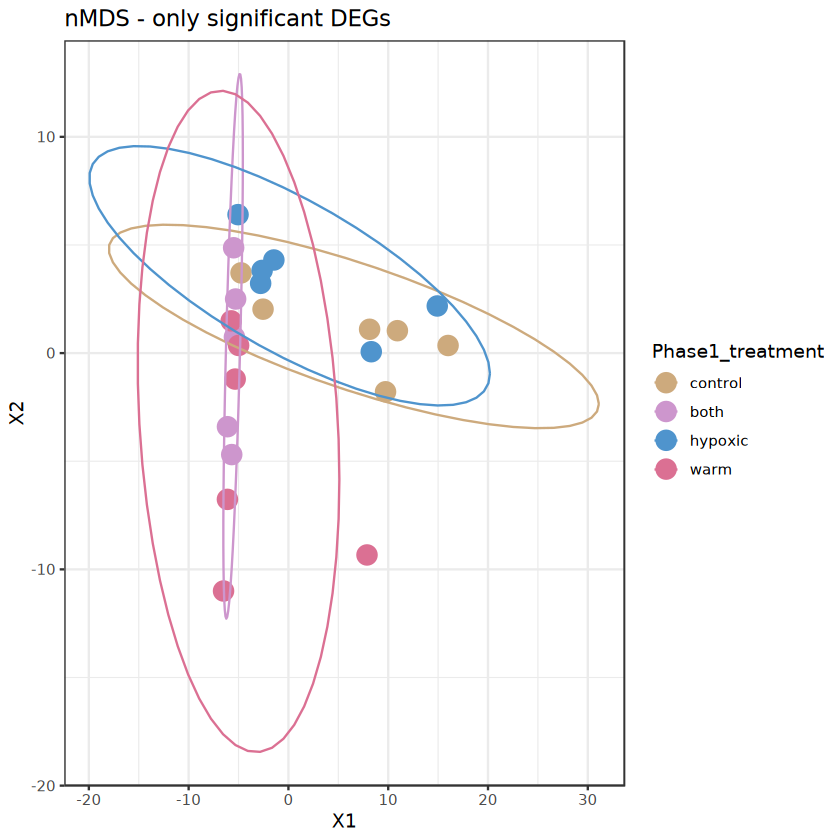

In [79]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

different patterns here vs. when we looked at all DEGs identified in any pairwise comparisons for phase 1 vs. phase 1
- warm is more dispersed
- both has tigher clustering

#### permanova

In [80]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

In [81]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,595.9570,0.15251716,3.8600353,0.002
Phase1_DO,1,273.7817,0.07006615,1.7732943,0.072
Phase1_temp:Phase1_DO,1,104.2960,0.02669140,0.6755288,0.786
Residual,19,2933.4402,0.75072529,NA,NA
Total,22,3907.4748,1.00000000,NA,NA
